In [1]:
# Import libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import dataset

data = pd.read_csv('../data/processed/processed_data.csv')

df = pd.DataFrame(data)

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Ticker,Return,MA_10,MA_50,Vol_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Year,Accum_Return
0,2021-06-14,124.707585,127.361347,123.975848,127.302811,96906500,AAPL,0.024578,123.173855,125.622075,0.011338,0.009833,-0.008024,0.003078,2021,0.024578
1,2021-06-15,126.775982,127.419915,126.239371,126.483284,62746300,AAPL,-0.006438,123.696806,125.699220,0.011668,0.024578,0.009833,-0.008024,2021,0.017982
2,2021-06-16,127.195487,127.702829,125.332007,126.980843,91815000,AAPL,0.003934,124.193413,125.780277,0.011647,-0.006438,0.024578,0.009833,2021,0.021987
3,2021-06-17,126.639398,129.322436,126.493042,128.580933,96721700,AAPL,0.012601,124.998326,125.860415,0.010381,0.003934,-0.006438,0.024578,2021,0.034865
4,2021-06-18,127.527230,128.307738,127.068673,127.283318,108953300,AAPL,-0.010092,125.444199,125.866680,0.010570,0.012601,0.003934,-0.006438,2021,0.024421


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          6035 non-null   str    
 1   Open          6035 non-null   float64
 2   High          6035 non-null   float64
 3   Low           6035 non-null   float64
 4   Close         6035 non-null   float64
 5   Volume        6035 non-null   int64  
 6   Ticker        6035 non-null   str    
 7   Return        6035 non-null   float64
 8   MA_10         6035 non-null   float64
 9   MA_50         6035 non-null   float64
 10  Vol_10        6035 non-null   float64
 11  Return_Lag_1  6035 non-null   float64
 12  Return_Lag_2  6035 non-null   float64
 13  Return_Lag_3  6035 non-null   float64
 14  Year          6035 non-null   int64  
 15  Accum_Return  6035 non-null   float64
dtypes: float64(12), int64(2), str(2)
memory usage: 754.5 KB


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Return,MA_10,MA_50,Vol_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Year,Accum_Return
count,6035.000000,6035.000000,6035.000000,6035.000000,6.035000e+03,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000
mean,228.975976,231.986525,225.871115,228.998385,5.558853e+07,0.000753,228.527005,226.163390,0.020879,0.000765,0.000762,0.000732,2023.338028,0.323252
std,100.201795,101.293430,98.883740,100.090727,3.659549e+07,0.023986,99.761143,98.007021,0.011816,0.023974,0.023971,0.023945,1.438176,0.412762
min,82.800003,83.480003,81.430000,81.820000,5.855900e+06,-0.154262,84.224001,90.546800,0.003132,-0.154262,-0.154262,-0.154262,2021.000000,-0.511060
25%,152.877789,154.996271,150.935194,153.268654,2.836565e+07,-0.010523,152.741547,152.648080,0.012709,-0.010502,-0.010502,-0.010502,2022.000000,0.044762
50%,203.490005,206.589586,200.101080,203.301331,4.569200e+07,0.000899,203.332793,202.008800,0.017677,0.000904,0.000904,0.000899,2023.000000,0.248717
75%,278.460813,282.106113,274.633344,278.452423,7.190070e+07,0.012175,278.236569,272.594416,0.025785,0.012175,0.012192,0.012130,2025.000000,0.572557
max,552.023241,552.242002,538.530591,539.825195,3.186799e+08,0.226900,523.633539,512.314614,0.093775,0.226900,0.226900,0.226900,2026.000000,1.849863


In [6]:
# Dropping NA

df = df.dropna(subset=['Return', 'MA_10', 'MA_50', 'Vol_10'])

In [7]:
# Updating date dtype

df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.describe()

,Date,Open,High,Low,Close,Volume,Return,MA_10,MA_50,Vol_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Year,Accum_Return
count,6035,6035.000000,6035.000000,6035.000000,6035.000000,6.035000e+03,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000,6035.000000
mean,2023-11-05 20:00:11.930406,228.975976,231.986525,225.871115,228.998385,5.558853e+07,0.000753,228.527005,226.163390,0.020879,0.000765,0.000762,0.000732,2023.338028,0.323252
min,2021-06-14 00:00:00,82.800003,83.480003,81.430000,81.820000,5.855900e+06,-0.154262,84.224001,90.546800,0.003132,-0.154262,-0.154262,-0.154262,2021.000000,-0.511060
25%,2022-08-23 00:00:00,152.877789,154.996271,150.935194,153.268654,2.836565e+07,-0.010523,152.741547,152.648080,0.012709,-0.010502,-0.010502,-0.010502,2022.000000,0.044762
50%,2023-11-03 00:00:00,203.490005,206.589586,200.101080,203.301331,4.569200e+07,0.000899,203.332793,202.008800,0.017677,0.000904,0.000904,0.000899,2023.000000,0.248717
75%,2025-01-21 00:00:00,278.460813,282.106113,274.633344,278.452423,7.190070e+07,0.012175,278.236569,272.594416,0.025785,0.012175,0.012192,0.012130,2025.000000,0.572557
max,2026-04-02 00:00:00,552.023241,552.242002,538.530591,539.825195,3.186799e+08,0.226900,523.633539,512.314614,0.093775,0.226900,0.226900,0.226900,2026.000000,1.849863
std,NaN,100.201795,101.293430,98.883740,100.090727,3.659549e+07,0.023986,99.761143,98.007021,0.011816,0.023974,0.023971,0.023945,1.438176,0.412762


In [9]:
# Accumulated return by Ticker

df_accum_ret = df.copy()
df_accum_ret['Accum_Return'] = (
    df_accum_ret
    .groupby('Ticker')['Return']
    .transform(lambda x: (1 + x).cumprod() - 1)
)

In [10]:
df_accum_ret.head(5)

,Date,Open,High,Low,Close,Volume,Ticker,Return,MA_10,MA_50,Vol_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Year,Accum_Return
0,2021-06-14,124.707585,127.361347,123.975848,127.302811,96906500,AAPL,0.024578,123.173855,125.622075,0.011338,0.009833,-0.008024,0.003078,2021,0.024578
1,2021-06-15,126.775982,127.419915,126.239371,126.483284,62746300,AAPL,-0.006438,123.696806,125.699220,0.011668,0.024578,0.009833,-0.008024,2021,0.017982
2,2021-06-16,127.195487,127.702829,125.332007,126.980843,91815000,AAPL,0.003934,124.193413,125.780277,0.011647,-0.006438,0.024578,0.009833,2021,0.021987
3,2021-06-17,126.639398,129.322436,126.493042,128.580933,96721700,AAPL,0.012601,124.998326,125.860415,0.010381,0.003934,-0.006438,0.024578,2021,0.034865
4,2021-06-18,127.527230,128.307738,127.068673,127.283318,108953300,AAPL,-0.010092,125.444199,125.866680,0.010570,0.012601,0.003934,-0.006438,2021,0.024421


In [11]:
df_accum_ret.loc[df_accum_ret['Date'] == '2026-03-27', ['Accum_Return','Date']]

,Accum_Return,Date
1202,1.002430,2026-03-27
2409,0.191217,2026-03-27
3616,1.276417,2026-03-27
4823,0.438402,2026-03-27
6030,0.779813,2026-03-27


In [12]:
total_return = (
    df_accum_ret.sort_values(['Ticker','Date'])
    .groupby('Ticker')['Accum_Return']
    .last()
    .reset_index(name='Accumulated Return')
)

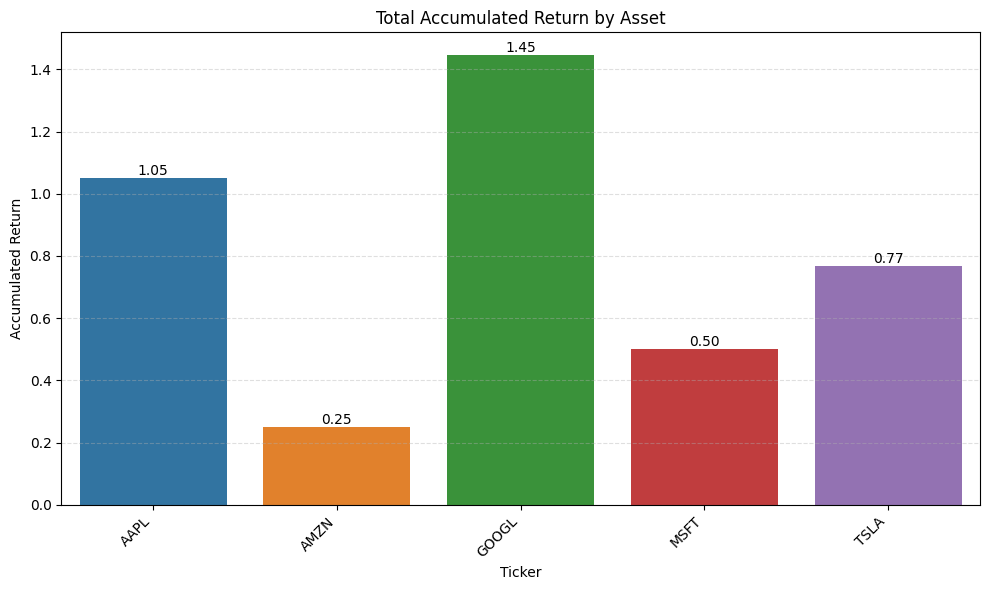

In [13]:
plt.figure(figsize=(10,6))

vis = sns.barplot(
    data=total_return,
    x='Ticker',
    y='Accumulated Return',
    hue='Ticker',
    palette='tab10'
)

for p in vis.patches:
    vis.annotate(
        format(p.get_height(), '.2f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

plt.title('Total Accumulated Return by Asset')
plt.xlabel('Ticker')
plt.ylabel('Accumulated Return')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [14]:
# Accumulated return by Year

df_accum_ret['Year'] = df_accum_ret['Date'].dt.year
accum_return_yearly = (
    df_accum_ret.groupby(['Ticker', 'Year'])['Return']
    .apply(lambda x: (1 + x).prod() -1)
    .reset_index(name='Accum_Return')
)

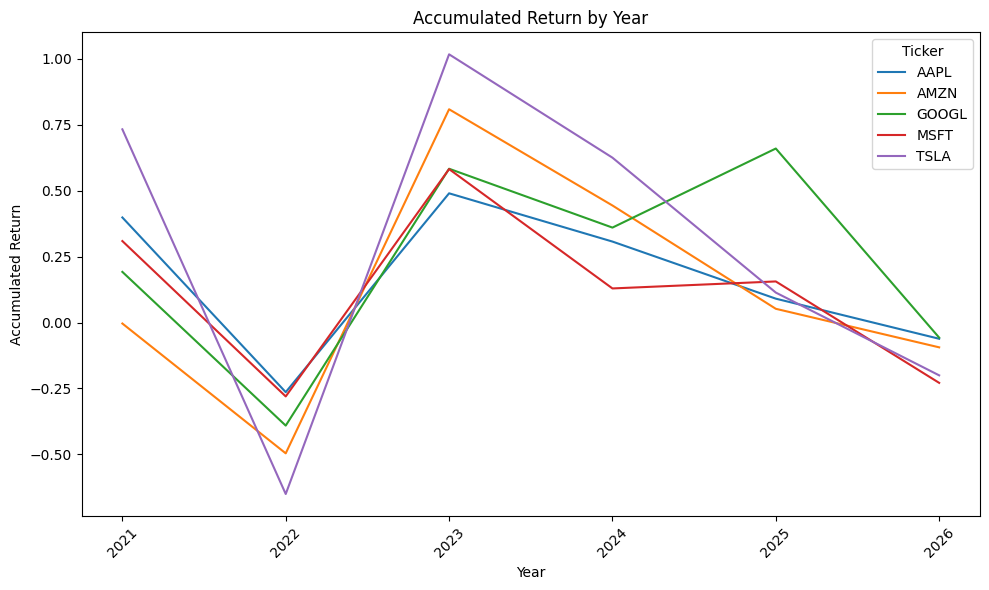

In [15]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=accum_return_yearly,
    x='Year',
    y='Accum_Return',
    hue='Ticker'
)
plt.title('Accumulated Return by Year')
plt.xlabel('Year')
plt.ylabel('Accumulated Return')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Price Evolution

df_price_evo = df.copy()
df_price_evo['Month'] = df_price_evo['Date'].dt.to_period('M')

In [17]:
monthly_close = (
    df_price_evo.set_index('Date')
      .groupby('Ticker')['Close']
      .resample('ME')
      .last()
      .reset_index()
)

In [18]:
print(monthly_close)

    Ticker       Date       Close
0     AAPL 2021-06-30  133.625061
1     AAPL 2021-07-31  142.308319
2     AAPL 2021-08-31  148.354858
3     AAPL 2021-09-30  138.261307
4     AAPL 2021-10-31  146.371323
..     ...        ...         ...
290   TSLA 2025-12-31  449.720001
291   TSLA 2026-01-31  430.410004
292   TSLA 2026-02-28  402.510010
293   TSLA 2026-03-31  371.750000
294   TSLA 2026-04-30  359.630005

[295 rows x 3 columns]


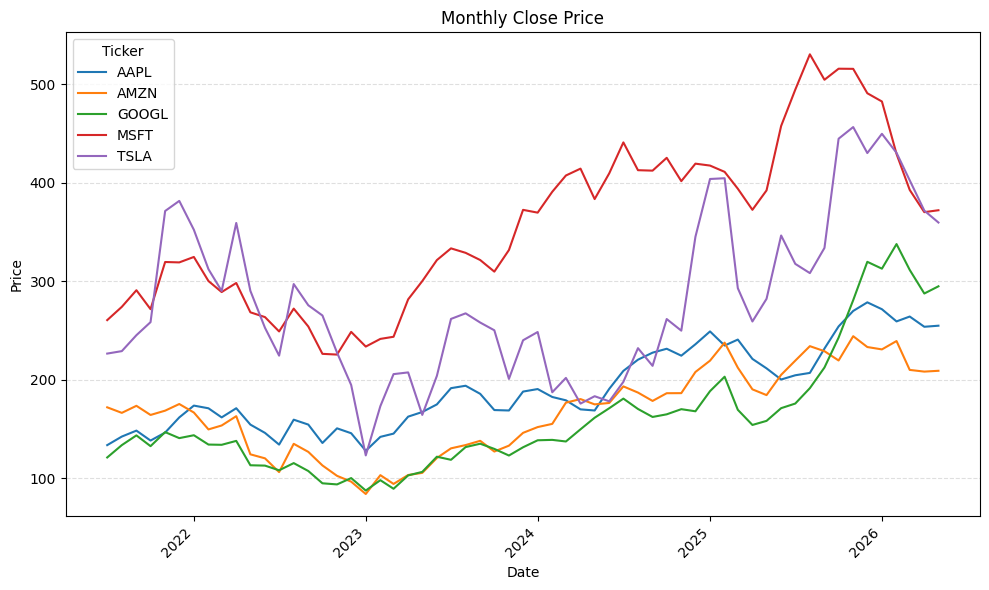

In [19]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=monthly_close,
    x='Date',
    y='Close',
    hue='Ticker'
)
plt.title('Monthly Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

O Google foi a empresa que apresentou maior retorno acumulado durante o período dos últimos 5 anos.
Todos ativos tiveram um crescimento significativo na metade do ano de 2025.


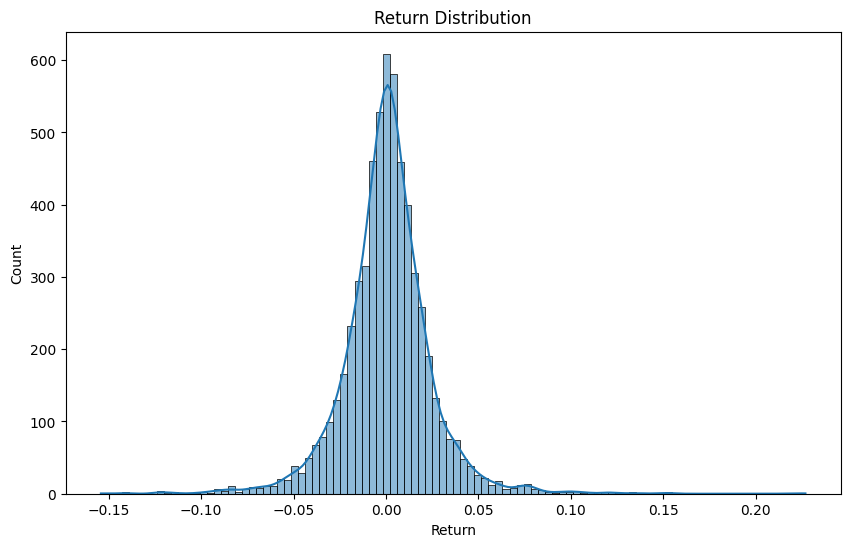

In [20]:
# Return Distribution

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_accum_ret['Return'],
    bins=100,
    kde=True
)
plt.title('Return Distribution')
plt.show()

In [21]:
# Mean, Median and Skewness

avg = df_accum_ret['Return'].mean().round(5)
median = df_accum_ret['Return'].median().round(5)
skewness = df_accum_ret['Return'].skew().round(5)

In [22]:
print(f'Mean = {avg}\nMedian = {median}\nSkewness = {skewness}')

Mean = 0.00075
Median = 0.0009
Skewness = 0.31535


In [23]:
# Calculating Volatility

volatility = (
    df.groupby('Ticker')['Return']
    .std()
    .reset_index(name='Volatility')
)

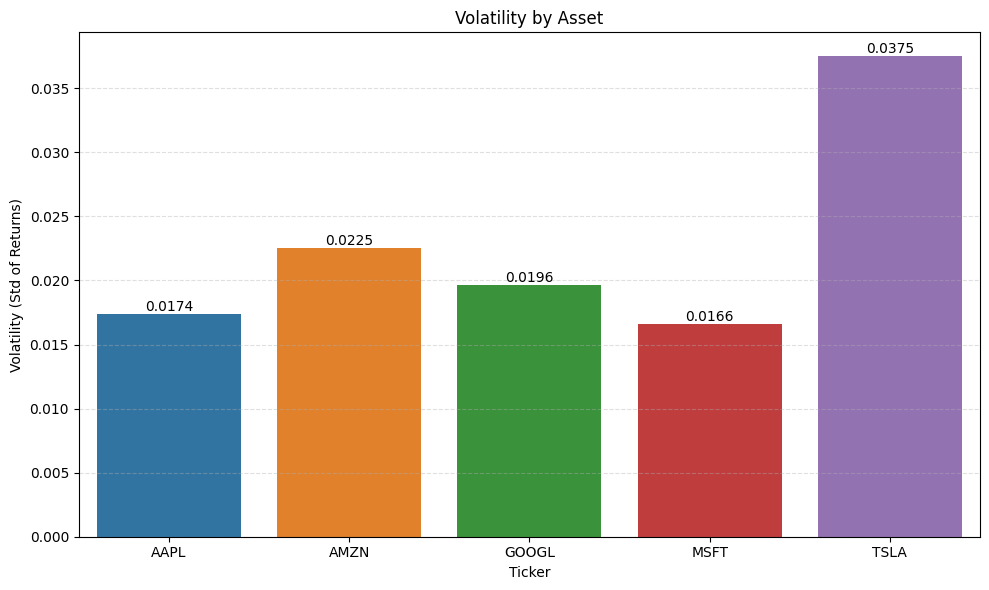

In [24]:
plt.figure(figsize=(10,6))
vis = sns.barplot(
    data=volatility,
    x='Ticker',
    y='Volatility',
    hue='Ticker',
    palette='tab10'
)

for p in vis.patches:
    vis.annotate(
        format(p.get_height(), '.4f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

plt.title('Volatility by Asset')
plt.ylabel('Volatility (Std of Returns)')
plt.xlabel('Ticker')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
volatility['Annualized_Vol'] = volatility['Volatility'] * np.sqrt(252)

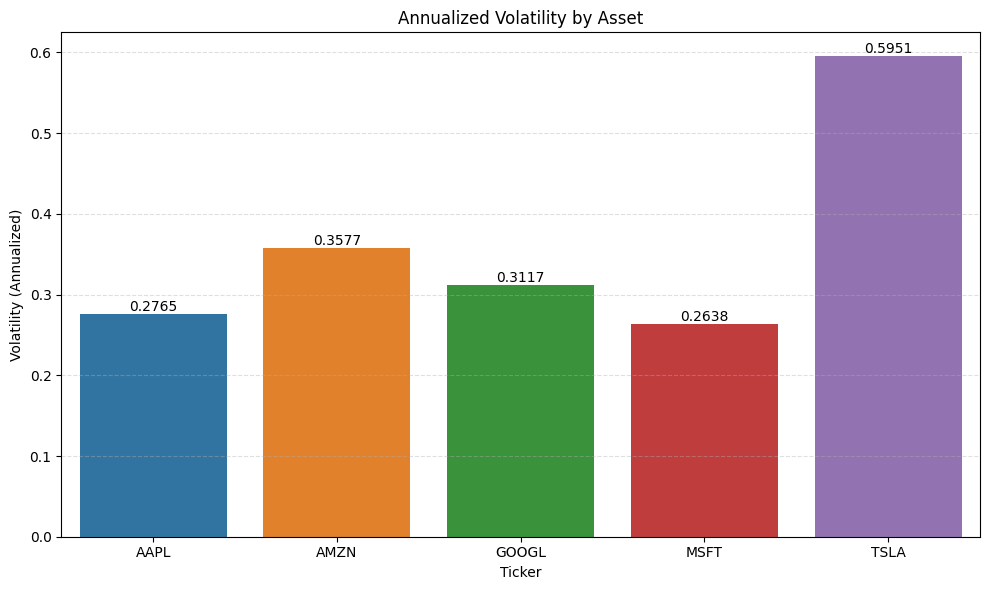

In [26]:
plt.figure(figsize=(10,6))
vis = sns.barplot(
    data=volatility,
    x='Ticker',
    y='Annualized_Vol',
    hue='Ticker',
    palette='tab10'
)

for p in vis.patches:
    vis.annotate(
        format(p.get_height(), '.4f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

plt.title('Annualized Volatility by Asset')
plt.ylabel('Volatility (Annualized)')
plt.xlabel('Ticker')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

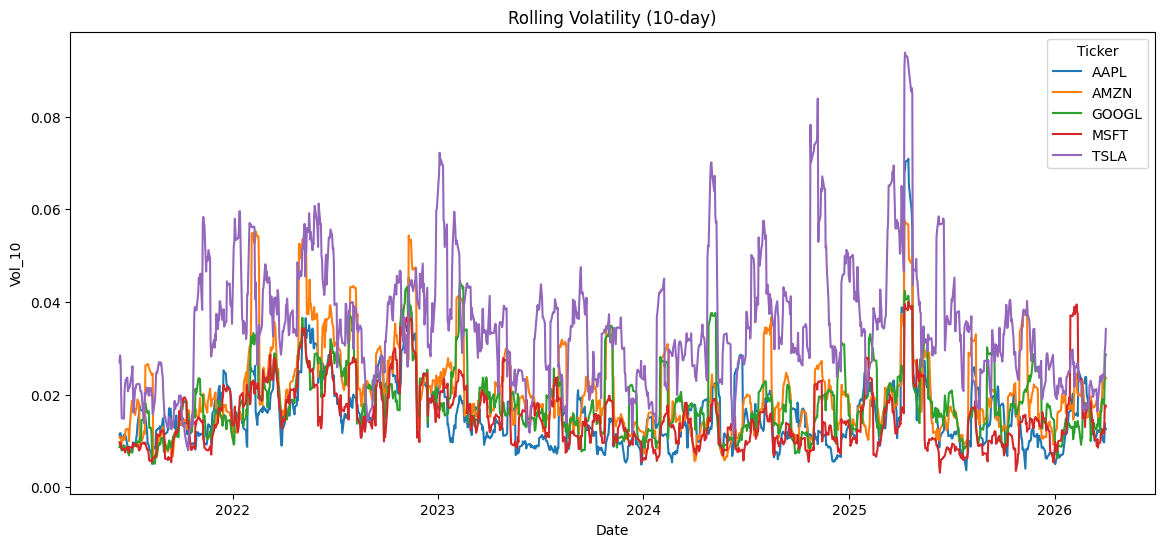

In [27]:
plt.figure(figsize=(14,6))
sns.lineplot(
    data=df,
    x='Date',
    y='Vol_10',
    hue='Ticker'
)
plt.title('Rolling Volatility (10-day)')
plt.show()

In [28]:
summary = (
    df.groupby('Ticker')['Return']
    .agg(['mean','std'])
    .reset_index()
)

summary['Vol_Annual'] = summary['std'] * np.sqrt(252)
summary['Return_Annual'] = summary['mean'] * 252

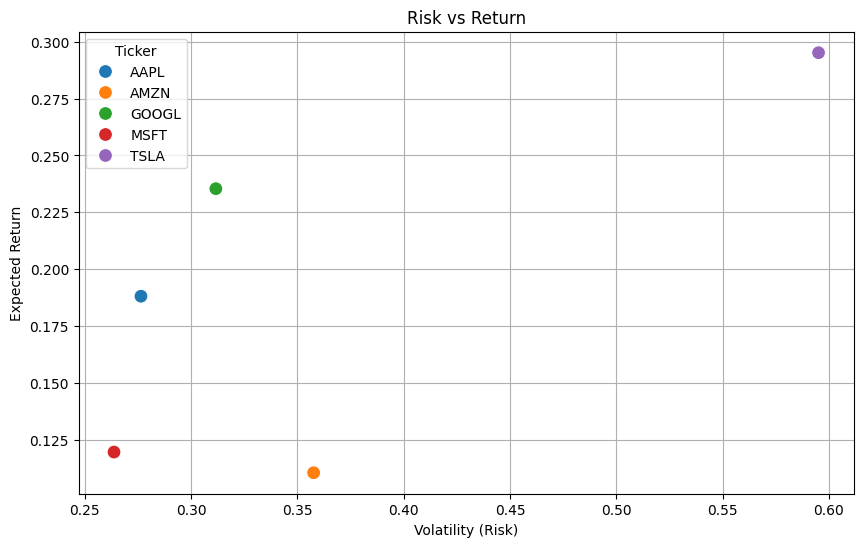

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=summary,
    x='Vol_Annual',
    y='Return_Annual',
    hue='Ticker',
    s=100
)

plt.title('Risk vs Return')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.grid(True)
plt.show()

A tesla é a empresa com maior volatilidade em todos cenários, teve sua maior volatilidade próximo a metade do ano de 2025.
Por mais que a tesla seja a ação mais volátil, a tesla apresenta o maior retorno esperado e também o maior risco.

In [30]:
# Correlation between assets

df_pivot = df.pivot(index='Date', columns='Ticker', values='Return')
corr_matrix = df_pivot.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

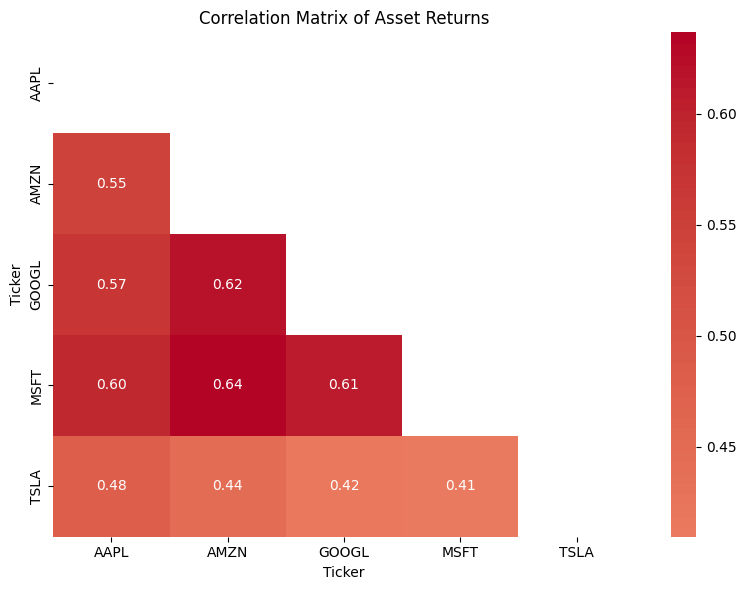

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    mask=mask
)
plt.title('Correlation Matrix of Asset Returns')
plt.tight_layout()
plt.show()

A maior correlação está entre Microsoft e Amazon.
Microsoft apresenta correlação relativamente forte com todos outros ativos.

In [32]:
# Calculating Drawdown

df_accum_ret['Peak'] = (
    df_accum_ret.groupby('Ticker')['Accum_Return']
    .transform(lambda x: x.cummax())
)
df_accum_ret['Drawdown'] = (
    (df_accum_ret['Accum_Return'] - df_accum_ret['Peak']) /
    (1 + df_accum_ret['Peak'])
)

In [33]:
df_accum_ret.head(3)

,Date,Open,High,Low,Close,Volume,Ticker,Return,MA_10,MA_50,Vol_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Year,Accum_Return,Peak,Drawdown
0,2021-06-14,124.707585,127.361347,123.975848,127.302811,96906500,AAPL,0.024578,123.173855,125.622075,0.011338,0.009833,-0.008024,0.003078,2021,0.024578,0.024578,0.000000
1,2021-06-15,126.775982,127.419915,126.239371,126.483284,62746300,AAPL,-0.006438,123.696806,125.699220,0.011668,0.024578,0.009833,-0.008024,2021,0.017982,0.024578,-0.006438
2,2021-06-16,127.195487,127.702829,125.332007,126.980843,91815000,AAPL,0.003934,124.193413,125.780277,0.011647,-0.006438,0.024578,0.009833,2021,0.021987,0.024578,-0.002529


In [34]:
max_dd = (
    df_accum_ret.groupby('Ticker')['Drawdown']
    .min()
    .reset_index(name='Max_Drawdown')
)

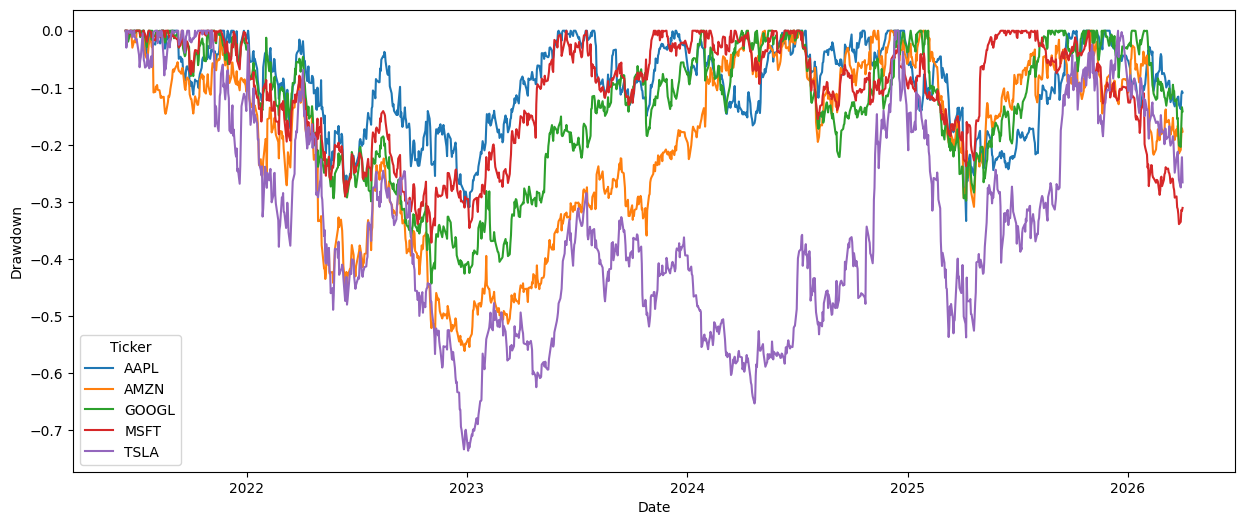

In [35]:
plt.figure(figsize=(15,6))
sns.lineplot(
    data=df_accum_ret,
    x='Date',
    y='Drawdown',
    hue='Ticker'
)
plt.show()

In [36]:
max_dd['Max_Drawdown'] = max_dd['Max_Drawdown'].abs() * 100
max_dd = max_dd.sort_values('Max_Drawdown', ascending=False)

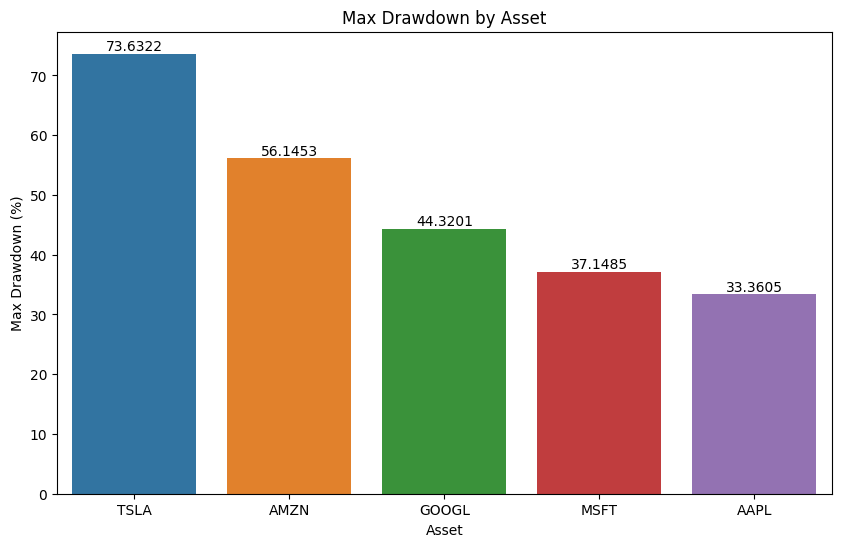

In [37]:
plt.figure(figsize=(10,6))
vis = sns.barplot(
    data=max_dd,
    x='Ticker',
    y='Max_Drawdown',
    hue='Ticker',
    palette='tab10'
)

for p in vis.patches:
    vis.annotate(
        format(p.get_height(), '.4f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10,
    )

plt.title('Max Drawdown by Asset')
vis.set_ylabel('Max Drawdown (%)')
vis.set_xlabel('Asset')
plt.show()

A Tesla apresentou o maior drawdown durante a maioria do periodo analisado.
O maior drawdown foi da Tesla, de 73,63%